# Chatbot with Message Summarization

## Review
We've covered how to customize graph state (`state_schema.ipynb`) and reducer (`state_reducer.ipynb`).

We've also shown a number of ways to trim or filter messages in graph state (`trim_filter_messages.ipynb`).

## Goals
Rather than just trimming or filtering messages, we'll show how to use LLMs to produce a running summary of the conversation.

This allows us to retain a compressed representation of the full conversation, rather than just removing it with trimming or filtering.

We'll incorporate this summarization into a simple Chatbot. And we'll equip that Chatbot with memory, supporting long-running conversations without incurring high token cost/latency.

In [3]:
# Import libraries
import os
from dotenv import load_dotenv

from langgraph.graph import MessagesState, END
from typing_extensions import Literal
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

# Set the Chat Model
model = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)

class State(MessagesState):
    summary: str

We'll define a node to call our LLM that incorporate a summary, if it exists, into the prompt.

In [4]:
# Define the logic to call the model
def call_model(state: State):
    summary = state.get("summary", "")
    if summary:
        system_message = f"Summary of conversation earlier: {summary}."
        messages = [SystemMessage(content=system_message) + state["messages"]]
    else:
        messages = state["messages"]
    response = model.invoke(messages)
    return {"messages": response}

# Define function to filter our state after we've produced the summary
def summarize_conversation(state: State):
    summary = state.get("summary", "")
    if summary:
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n."
            "Extend the summary by taking into account the new messages above: "
        )
    else:
        summary_message = "Create a summary of the conversation above: "

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State) -> Literal ["summarize_conversation", END]:
    messages = state["messages"]
    # If there are more than 6 messages, we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    return END

## Adding Memory
Recall that state is transient to a single graph execution. This limits our ability to have multi-turn conversations with interruptions. As introduced at the end of Module 1, we can use persistence to address this.

LangGraph can use checkpointer to automatically save the graph state after each step. This built-in persistence layer provides memory, allowing LangGraph to resume from the last state update.

As we previously showed, one of the easiest to work with is `MemorySaver`, as in-memory key-value store for Graph state. All we need to do is compile the graph with a checkpointer, and our graph has memory.

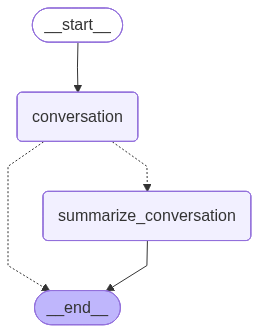

In [5]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node("summarize_conversation", summarize_conversation)

# Logic
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

## Threads
The checkpointer saves the state at each step as a checkpoint. These saved checkpoints can be grouped into a `thread` of conversation.

Think about Slack as an analog: different channels carry different conversations. Threads are like Slack channels, capturing grouped collections of state (e.g., conversation).

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start Conversation
input_message = HumanMessage(content="Hi! I'm Lance.")
output = graph.invoke({"messages": [input_message]}, config)
for m in output["messages"][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="What's my name?")
output = graph.invoke({"messages": [input_message]}, config)
for m in output["messages"][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="I like the 49ers.")
output = graph.invoke({"messages": [input_message]}, config)
for m in output["messages"][-1:]:
    m.pretty_print()